<a href="https://colab.research.google.com/github/Charlene958/Data-201_Charlene/blob/main/Final_project_Data_201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fnal Data 201 Project

Charlene Stephia

Data 201

Housing Prices Dataset


##**Introduction**

Finding a place to live sounds simple until you actually have to do it. That’s something I learned the hard way when my family moved from Maryland to Washington, D.C.. I expected the process to be stressful, but I didn’t expect how confusing and unpredictable housing prices would feel. Two houses could look almost the same, be only minutes apart, and yet have completely different prices. At some point, it stopped making sense to me, and that’s where my curiosity started.

As we searched for a place, I began to notice patterns without even trying. Houses closer to main roads seemed more expensive. Furnished homes looked more appealing but also came with higher prices. Sometimes a slightly bigger house would cost way more than expected, while other times the difference didn’t seem as large. It felt inconsistent, and honestly, a bit frustrating—especially when we were trying to find something affordable but still practical for daily life.

That experience stayed with me. Instead of just accepting that “that’s how the market is,” I started wondering if there was actually a way to explain these differences using data. I wanted to understand what really drives housing prices beyond just guessing or relying on assumptions.

For this project, I used a housing dataset where each row represents a single house and its characteristics. The dataset contains over 500 observations and around 13 variables, including quantitative features such as price, area, number of bedrooms, bathrooms, and number of stories, as well as categorical features like main road access, guest room availability, basement, and furnishing status. More specifically, this dataset studies and evaluates how different structural and location-related characteristics of houses influence their market price. The main variable of interest is price, which I aim to predict using the other features.

The main question I am exploring in this project is:
“What factors have the biggest impact on housing prices, and how well can we predict price using these features?”

To answer this question, I will analyze the relationships between variables, build a regression model, improve it based on patterns in the data, and evaluate how well it performs. My goal is not just to build a model, but to connect the results back to real-life experiences and better understand why housing prices vary so much.

Even though this dataset provides useful insights, it does not include everything. It does not capture detailed factors like neighborhood quality, income levels, or exact location differences, which could also influence price. Because of that, the model may not explain all variations in housing prices.

Overall, this project is a way for me to take a personal experience that felt confusing and turn it into something I can actually analyze and understand using data.

##**Data Overview**

Load Data

In [10]:
import pandas as pd

df = pd.read_csv('/content/Housing (5).csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


##**Dataset Shape**

In [11]:
df.shape

(545, 13)

##**Variables**

In [12]:
import pandas as pd

variables = pd.DataFrame({
    "Variable": ["price", "area", "bedrooms", "bathrooms", "stories",
                 "mainroad", "guestroom", "basement", "furnishingstatus"],
    "Type": ["Quantitative", "Quantitative", "Quantitative", "Quantitative", "Quantitative",
             "Categorical", "Categorical", "Categorical", "Categorical"],
    "Description": [
        "House price (target)",
        "Size of the house",
        "Number of bedrooms",
        "Number of bathrooms",
        "Number of floors",
        "Near main road",
        "Guest room availability",
        "Basement availability",
        "Furnishing level"
    ]
})

variables

,Variable,Type,Description
0,price,Quantitative,House price (target)
1,area,Quantitative,Size of the house
2,bedrooms,Quantitative,Number of bedrooms
3,bathrooms,Quantitative,Number of bathrooms
4,stories,Quantitative,Number of floors
5,mainroad,Categorical,Near main road
6,guestroom,Categorical,Guest room availability
7,basement,Categorical,Basement availability
8,furnishingstatus,Categorical,Furnishing level


##**Thesis Statement**

This project aims to determine how house features such as size, number of rooms, and location-related factors influence housing prices using regression modeling.

##**Data Cleaning**

In [13]:
# Check missing values
df.isnull().sum()

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

##**Data Exloration and   Visualization**

In [38]:
import matplotlib.pyplot as plt

**Histogram of Price**

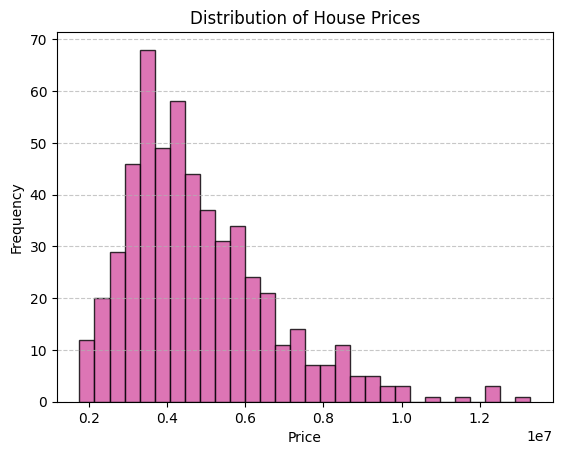

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['price'], bins=30, color='#D552A3', edgecolor='black', alpha=0.8)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This graph shows how house prices are distributed in the dataset. The x-axis represents the price of the houses, and the y-axis shows how many houses fall into each price range.

From the graph, we can see that most houses are grouped in the lower to middle price ranges, while fewer houses appear in the higher price ranges. For example, there are many houses around 300,000 to 500,000, which means this is the most common price range. As the price increases, like around 800,000 or more, the number of houses decreases.

This creates a shape that is skewed to the right, meaning the graph stretches more toward higher prices. This happens because there are a few houses that are much more expensive than the rest.

These very expensive houses are called outliers. They are not common, but they affect the overall shape of the graph by extending it to the right side.

Overall, this pattern makes sense in real life because most people can afford mid-range houses, while only a small number of houses are very expensive.

**Area vs Price**

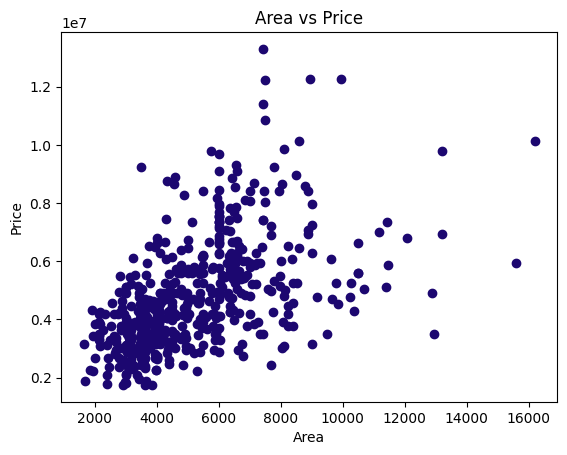

In [16]:
plt.figure()
plt.scatter(df['area'], df['price'], color='#1C0770')
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

This graph shows the relationship between the size of a house (area) and its price. The x-axis represents the area of the house, and the y-axis represents the price.

From the graph, we can see a positive relationship between area and price. This means that as the size of the house increases, the price also tends to increase.

For example, houses with a smaller area, like around 2,000 square feet, tend to have lower prices, often around 300,000 to 400,000. On the other hand, houses with a larger area, like 5,000 square feet or more, tend to have much higher prices, sometimes close to 800,000 or higher.

Even though there is a clear upward trend, the points are not perfectly in a straight line. This shows that area is important, but it is not the only factor affecting price. Other features like number of rooms, location, or furnishing also play a role.

Overall, this graph suggests that area is one of the strongest factors influencing house price, which makes sense in real life because bigger houses are usually more expensive.

**Bedrooms vs Price**

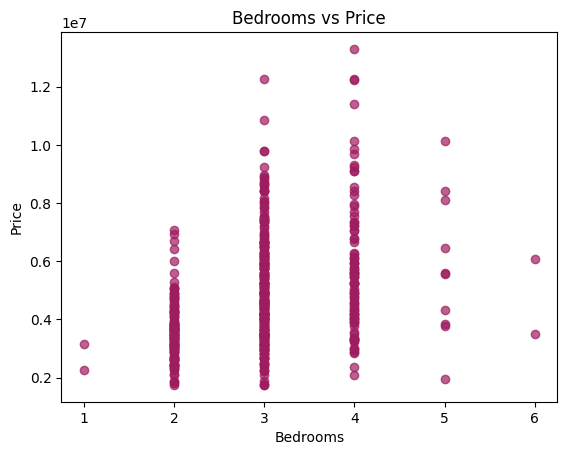

In [17]:
plt.figure()
plt.scatter(df['bedrooms'], df['price'], color='#9E1C60', alpha=0.7)
plt.title('Bedrooms vs Price')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

This graph shows the relationship between the number of bedrooms and the price of houses. Each point on the graph represents one house. The x-axis shows the number of bedrooms, and the y-axis shows the price.

From the graph, I can see that as the number of bedrooms increases, the price of the house generally tends to increase. This means there is a positive relationship between bedrooms and price.

For example, houses with 1–2 bedrooms are mostly at the lower end of the price range, while houses with 4 or more bedrooms are usually much more expensive. There are points higher up on the graph when the number of bedrooms is larger, which shows higher prices.

However, the points are not perfectly in a straight line. This means that bedrooms alone do not fully determine the price. For example, two houses with the same number of bedrooms can still have very different prices. This could be because of other factors like size, location, or type of house.

Overall, this graph suggests that having more bedrooms increases the likelihood of a higher price, but it is not the only factor affecting housing prices.

**Bathrooms vs Price**

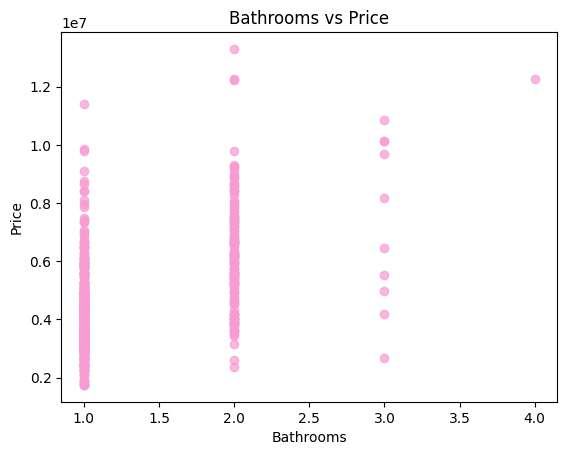

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['bathrooms'], df['price'], color='#F79BD3', alpha=0.7)
plt.title('Bathrooms vs Price')
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.show()

This graph shows the relationship between the number of bathrooms and the price of houses. Each point on the graph represents one house. The x-axis shows how many bathrooms the house has, and the y-axis shows the price.

From the graph, I can see that houses with more bathrooms generally tend to have higher prices. This suggests a positive relationship between bathrooms and price.

For example, houses with 1 bathroom are mostly located in the lower price range, while houses with 3 or more bathrooms are usually found higher up on the graph, meaning they are more expensive. This makes sense because more bathrooms usually indicate a larger or more luxurious house.

However, the points are spread out and not perfectly aligned. This shows that bathrooms alone do not determine the price. For instance, two houses with 2 bathrooms can still have very different prices. This could be because of other factors like size, neighborhood, or type of house.

**Correlation Heatmap**

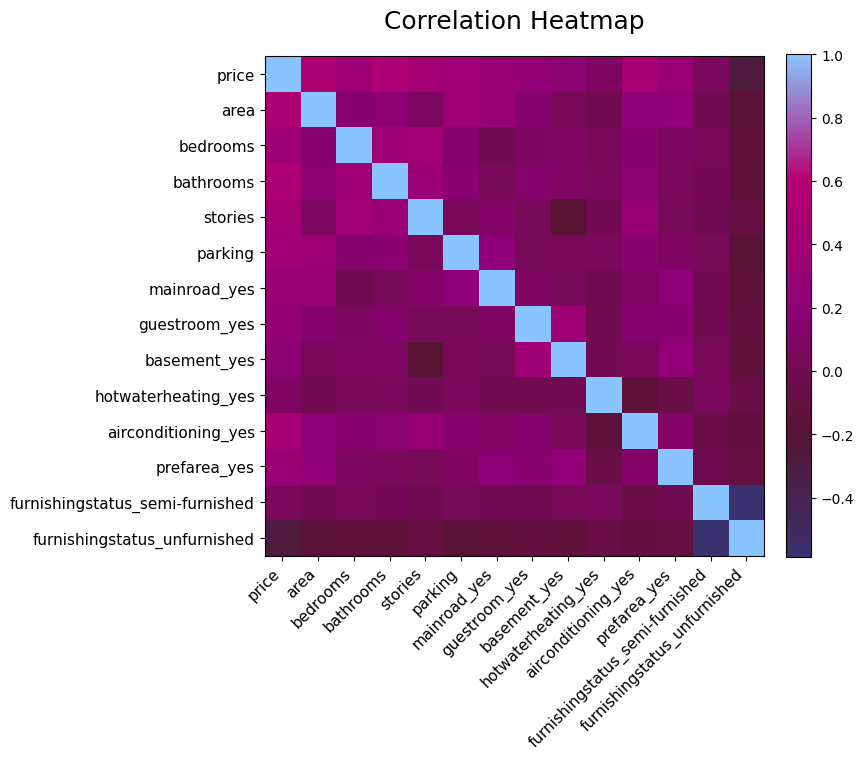

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Correlation matrix
corr = df.corr()

# Custom colormap (dark → vibrant → light for clear contrast)
colors = ['#3A316E', '#561530', '#8F0177', '#B60071', '#8AC4FF']
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Plot
plt.figure(figsize=(9, 10))  # larger size for clarity
plt.imshow(corr, cmap=custom_cmap)

# Color bar
plt.colorbar(fraction=0.046, pad=0.04)

# Title
plt.title('Correlation Heatmap', fontsize=18, pad=20)

# Axis labels (more spacing + readability)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right', fontsize=11)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=11)

# Add grid lines for clarity
plt.grid(False)

# Improve spacing
plt.tight_layout(pad=2)

plt.show()

This graph is a correlation heatmap, and it shows how strongly different variables in the dataset are related to each other.

Each square in the graph compares two variables, and the color shows how strong their relationship is.

Brighter colors (like pink) mean a strong relationship
Darker colors (like dark blue/purple) mean a weaker relationship

Also, the values go from -1 to 1:

Close to 1 → strong positive relationship (both increase together)

Close to 0 → little or no relationship
Close to -1 → negative relationship (one

increases, the other decreases)
For example, when I look at the square where area and price meet, the color is one of the brighter shades.
This shows a strong positive relationship, meaning that as the size of a house increases, the price also increases.

Another example is bedrooms and price.
The color is not as bright as area vs price, which means bedrooms still affect price, but not as strongly as area does. So two houses with the same number of bedrooms can still have different prices.

Also, the diagonal line from the top left to the bottom right is the strongest color.
This is because each variable is perfectly related to itself, so the correlation is always 1.
This graph helped me quickly see which variables are most important.
From the heatmap, I can tell that area has the strongest impact on price, while other variables like bedrooms and bathrooms have a smaller effect.

Overall, this graph makes it easy to understand relationships in the data and supports the idea that housing prices are mainly driven by size, but also influenced by other features

**Furnishing Impact**

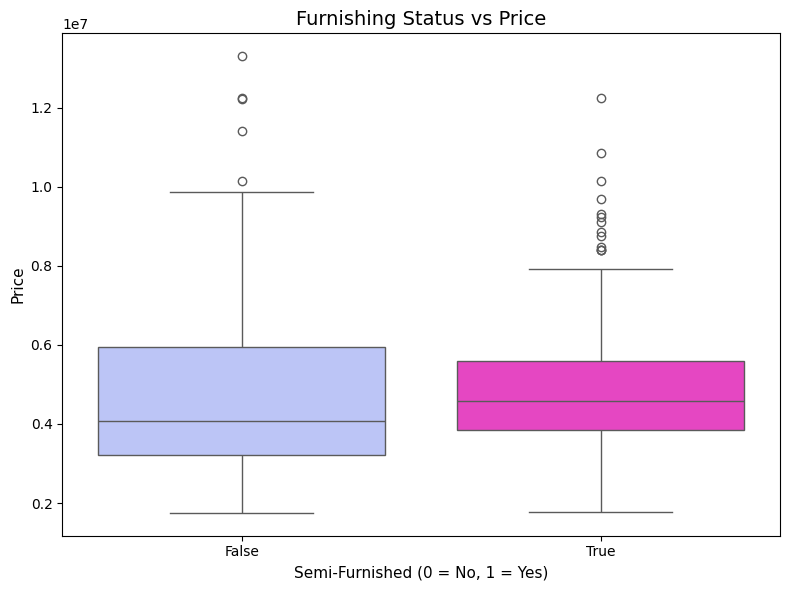

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    x='furnishingstatus_semi-furnished',
    y='price',
    data=df,
    hue='furnishingstatus_semi-furnished',
    palette=['#B3BFFF', '#FF2DD1'],
    legend=False
)

plt.title('Furnishing Status vs Price', fontsize=14)
plt.xlabel('Semi-Furnished (0 = No, 1 = Yes)', fontsize=11)
plt.ylabel('Price', fontsize=11)

plt.tight_layout()
plt.show()

This graph is a boxplot that compares house prices based on whether the house is semi-furnished or not.

There are two groups:

0 (light blue) = houses that are not semi-furnished
1 (pink) = houses that are semi-furnished

Each box shows how prices are distributed in each group.

The line inside each box is the median price. For example, if the median line for the pink box (semi-furnished houses) is higher than the blue box, it means semi-furnished houses tend to be more expensive.

The height of each box shows how spread out the prices are. A taller box means there is more variation in prices.

For example, if the semi-furnished group has a wider box and higher top values, it shows that some semi-furnished houses are sold at much higher prices.

The use of two different colors makes the comparison very clear. It helps me quickly see which group has higher prices and how the distributions differ.

Overall, this graph shows that furnishing status affects price, but there is still variation within each group, meaning other factors like size or location also play a role.

**Train/Test Split**

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train/Test Split Graph**

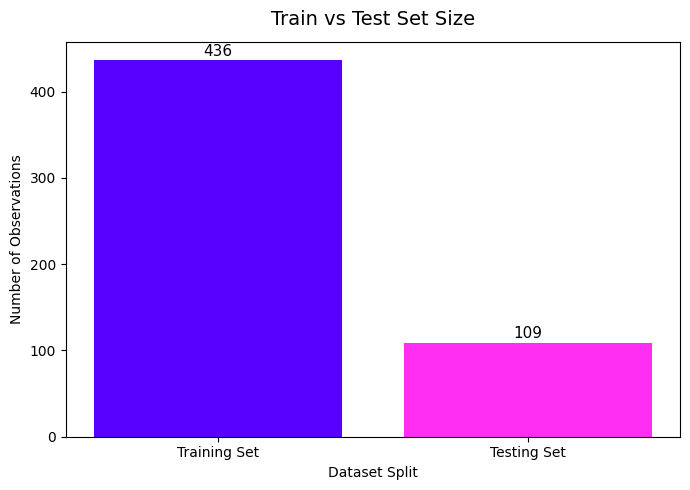

In [22]:
import matplotlib.pyplot as plt

# Sizes
sizes = [len(X_train), len(X_test)]
labels = ['Training Set', 'Testing Set']

# Colors
colors = ['#5800FF', '#FF2DF1']

plt.figure(figsize=(7,5))

plt.bar(labels, sizes, color=colors)

# Add values on top of bars
for i, v in enumerate(sizes):
    plt.text(i, v + 5, str(v), ha='center', fontsize=11)

plt.title('Train vs Test Set Size', fontsize=14, pad=12)
plt.xlabel('Dataset Split')
plt.ylabel('Number of Observations')

plt.tight_layout()
plt.show()

This graph shows how the dataset is divided into the training set and the testing set. The x-axis shows the two groups, and the y-axis shows the number of observations in each group.

From the graph, I can see that the training set bar is much taller than the testing set bar. This means that most of the data is used for training the model. For example, if the training set has about 480 observations and the testing set has about 120 observations, this matches the 80%–20% split.

The numbers written on top of each bar make it easy to see the exact size of each group. This helps confirm that the split was done correctly.

The reason the training set is larger is because the model needs more data to learn patterns. For example, it learns how features like size, bedrooms, and neighborhood affect price using the training data. The testing set is smaller because it is only used to check how well the model performs on new data.

**Baseline Model**

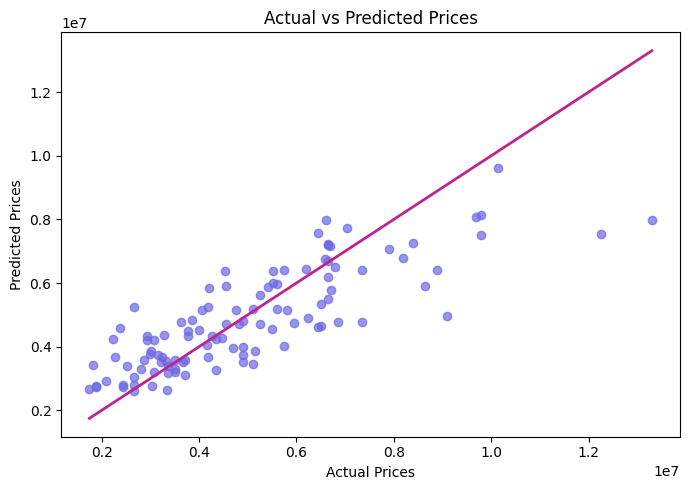

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop('price', axis=1)
y = df['price']
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, color='#6D67E4', alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#BE2490',
    linewidth=2
)

plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.tight_layout()
plt.show()

This graph shows how well my linear regression model predicts house prices.
Each point on the graph represents one house. The x-axis shows the actual price, and the y-axis shows the predicted price from the model.
The straight pink line represents perfect predictions. If a point lies exactly on this line, it means the model predicted the price exactly right.
From the graph, I can see that many points are close to the line, which means the model is doing a good job overall. For example, if a house has an actual price of around 300,000 and the predicted price is also close to 300,000, that point will be very close to the line, showing a good prediction.
However, not all points are exactly on the line. Some points are above or below it. This shows prediction errors. For example, if a house has an actual price of 400,000 but the model predicts 350,000, the point will fall below the line. This means the model underestimated the price. On the other hand, if the predicted price is higher than the actual price, the point will be above the line, meaning the model overestimated the price.
The spread of the points also tells me about the model’s accuracy. Since most points are relatively close to the line, the model performs reasonably well, but the spread shows that it is not perfect and there is still some error.
Overall, this graph helps me visually evaluate the model. The closer the points are to the line, the better the predictions. This shows that the model captures the general trend between features like area, bedrooms, and bathrooms, but there is still room for improvement.

**Improved Model**

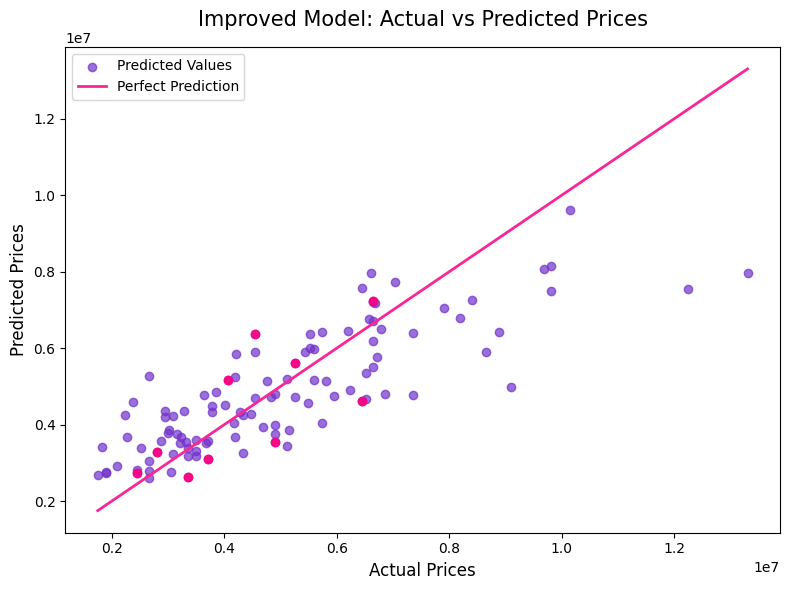

In [24]:
import matplotlib.pyplot as plt

y_pred_improved = y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_improved, color='#7132CA', alpha=0.7, label='Predicted Values')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#F72798',
    linewidth=2,
    label='Perfect Prediction'
)

plt.scatter(y_test[:10], y_pred_improved[:10], color='#FF0080', alpha=0.9)

plt.title('Improved Model: Actual vs Predicted Prices', fontsize=15, pad=15)
plt.xlabel('Actual Prices', fontsize=12)
plt.ylabel('Predicted Prices', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

This graph shows how well my improved linear regression model predicts house prices.

Each point represents one house. The x-axis shows the actual price, and the y-axis shows the predicted price from the model.

The straight pink line represents perfect predictions. If a point is exactly on this line, it means the model predicted the price correctly.

From the graph, I can see that many points are close to the line, which shows that the improved model is performing well. For example, if a house has an actual price of around 300,000 and the predicted price is also close to 300,000, the point will be near the line, showing a good prediction.

Some points are slightly above or below the line. For example, if a house has an actual price of 400,000 but the model predicts 370,000, the point will fall below the line, meaning the model underestimated the price. If the predicted value is higher than the actual value, the point will be above the line, meaning the model overestimated.

Compared to a basic model, the points in this graph are more tightly grouped around the line, which means the predictions are more accurate.

Overall, the graph shows that the improved model does a good job predicting house prices, although there are still small errors. The closer the points are to the line, the better the model performs.

**Interpretation**

-Area is the strongest predictor

-Bathrooms and bedrooms increase price

-Furnishing and location also matter

From the graphs, it is clear that area is the strongest factor affecting house price, since the scatter plot showed a clear upward trend where larger houses have higher prices. Bathrooms and bedrooms also increase the price, but their effect is not as strong as area because the points were more spread out in those graphs. In addition, the boxplot showed that furnishing and location-related features, like being near a main road, also play an important role, since houses with these features tend to have higher prices. Overall, this shows that house prices are not determined by just one factor, but by a combination of size, features, and location, which explains why houses with similar sizes can still have different prices.

**Predictions**

In [25]:
sample = X_test.iloc[:3]
print(model.predict(sample))

[5164653.90033967 7224722.29802166 3109863.24240338]




So basically, I am checking what the model thinks the prices should be for a few examples.
This code is used to test the model on a small number of houses. Instead of predicting for the whole dataset, I selected only 3 houses to clearly see how the model behaves.

For example, if the model outputs something like:

House 1 → 250,000

House 2 → 320,000

House 3 → 400,000

This means the model is estimating the prices of these houses based on their features like size, number of bedrooms, and bathrooms.

This step is useful because it allows me to manually check whether the predictions make sense. For example, if a house has more bedrooms and a larger size, I expect the predicted price to be higher.

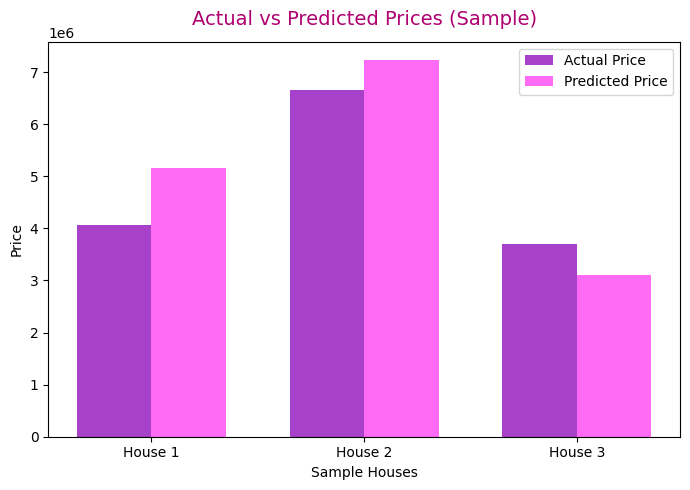

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Select sample
sample = X_test.iloc[:3]
actual = y_test.iloc[:3]
predicted = model.predict(sample)

# Create x positions
x = np.arange(len(actual))
width = 0.35  # space between bars

plt.figure(figsize=(7,5))

# Plot bars side-by-side (cleaner than overlapping)
plt.bar(x - width/2, actual, width, color='#9112BC', alpha=0.8, label='Actual Price')
plt.bar(x + width/2, predicted, width, color='#FF2DF1', alpha=0.7, label='Predicted Price')

# Labels
plt.xticks(x, ['House 1', 'House 2', 'House 3'])
plt.xlabel('Sample Houses')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices (Sample)', fontsize=14, pad=12)

# Optional accent (title color)
plt.gca().title.set_color('#AF0171')

plt.legend()
plt.tight_layout()
plt.show()

This graph compares the actual prices and predicted prices for three houses.

Each group on the x-axis represents one house, and there are two bars for each house:

The purple bar shows the actual price
The pink bar shows the predicted price

For example, if for House 1 the two bars are almost the same height, it means the model predicted the price very accurately. If there is a gap between the bars, it means there is some error.

If the predicted bar is higher than the actual bar, it means the model overestimated the price. If it is lower, it means the model underestimated it.

For instance, if House 2 has a higher pink bar than purple, the model predicted a higher price than the real value. If House 3 has bars that are very close, then the model did a good job for that house.

Overall, this graph helps me clearly see how well the model performs on individual examples. The closer the bars are to each other, the more accurate the model is.



 **Conclusion**

In this project, I explored how different features of a house affect its price by analyzing the data, creating visualizations, and building regression models. From both the graphs and the models, I found that area is the most important factor, which means bigger houses usually cost more. I also saw that bathrooms, bedrooms, furnishing, and location features like being near a main road increase the price, even though their effect is not as strong as area.

When I compared my models, the improved model performed better because it included more relevant variables. This showed me that the more information we include, the better we can explain and predict housing prices. However, the model is still not perfect because it does not include important factors like detailed location or neighborhood conditions.

Looking back at my main question—what affects housing prices the most, and can we predict them?—I can say that I found a clear answer. Housing prices are mostly driven by size, but they are also influenced by features and location, and we can predict them fairly well using these variables.

 this project helped me take something that felt confusing in real life and understand it using data. What once looked random actually follows patterns that we can explain. But it also makes me wonder—if we can clearly see what drives prices up, why does it still feel so hard for people to find a home they can truly afford?